## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?

- Regression is used for numerical variables while classification is used for categorical variables.

2. What is a confusion table/matrix? What does it help us understand about a model's performance?

- A confusion table is a table that cross-tabulates predicted labels with true ones to visualize if the model is performing well or not.

3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?

- Accuracy is the proportion of cases that the model predicted. However, it does not account for classes that show up less that can cause it to be misleading.

4. What does the root mean squared error quantify about a particular model?

- RMSE is the distance of the model's predicted values to the true ones and weighted for sample size, allowing for larger errors to penalized more.

5. What are overfitting and underfitting?

- Overfitting occurs when the model is too receptive to training data while performing poorly on data that is new caused by picking a k too low. Underfitting occurs when the model generalizes across the data but performs poorly on both training and new data.

6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?

- The training set is used to train the model, while the testing set allows one to measure to measure its performance by using new data. By testing different k values on the training set and choosing the best accuracy or RMSE would allow you to choose the best model that generalizes.

7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

- A class label as a prediction gives a definite result. Probability distribution provides a result where we can see the likelihood of each target variable. A class label is useful when we need a clear answer, however there is no confidence metric provided. A probability distribution is useful when the answer can be more vague and you can adjust the probability metric to find the most optimal solution.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.

- I iterated through odd numbers using a grid search to find the value for k that would give me the highest accuracy and landed at the value of 13.

4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?

- The accuracy was 41.42%. Performance was more accurate for mine types 1 and 2 and was overall inaccurate and tended to mispredict mine types 3, 4, and 5.

5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

- In practice, I would have the highest confidence in predictions labeled as Type 2 mines, since the model achieved its strongest accuracy for that category. However, as mines are high stakes problems I would be highly cautious and recommend against using the model for types 3, 4 and 5 due to the poor performance of the model, especially on type 5.

In [17]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

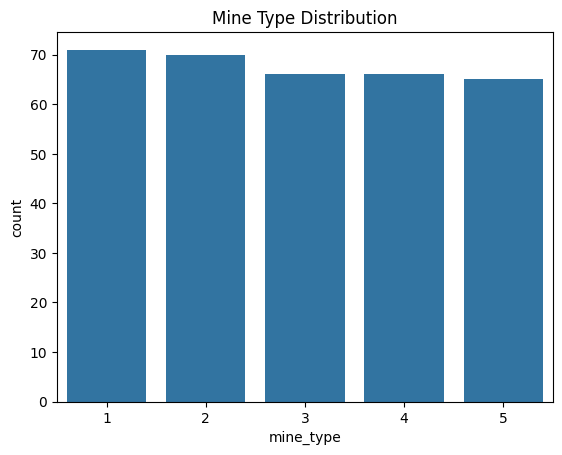

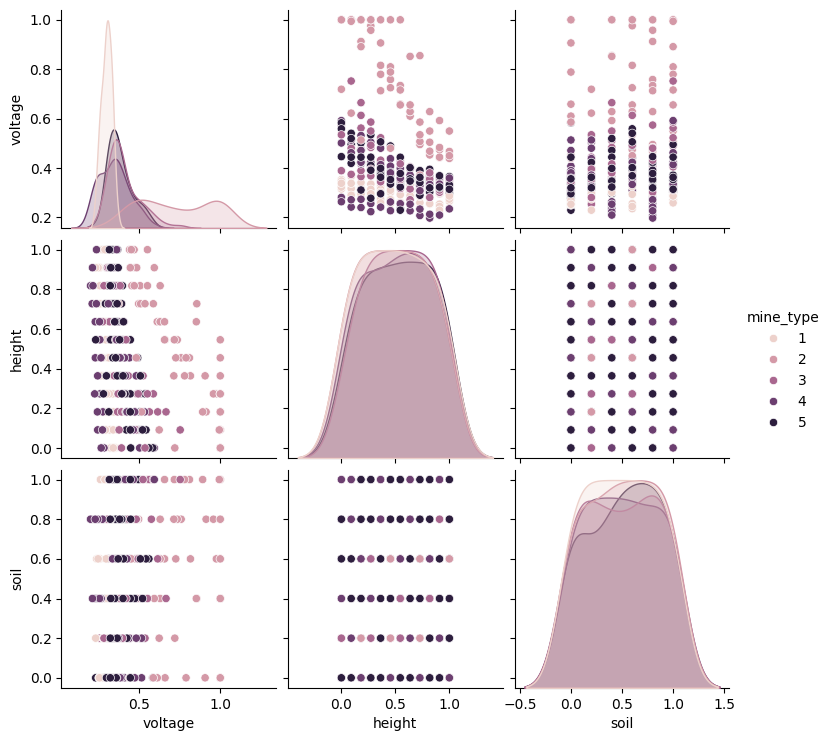

Test accuracy for 1 neighbors is 0.40236686390532544; train accuracy for 1 neighbors is 1.0
Test accuracy for 3 neighbors is 0.40828402366863903; train accuracy for 3 neighbors is 0.6449704142011834
Test accuracy for 5 neighbors is 0.3905325443786982; train accuracy for 5 neighbors is 0.5739644970414202
Test accuracy for 7 neighbors is 0.3668639053254438; train accuracy for 7 neighbors is 0.5798816568047337
Test accuracy for 9 neighbors is 0.378698224852071; train accuracy for 9 neighbors is 0.5266272189349113
Test accuracy for 11 neighbors is 0.40828402366863903; train accuracy for 11 neighbors is 0.5207100591715976
Test accuracy for 13 neighbors is 0.41420118343195267; train accuracy for 13 neighbors is 0.5325443786982249
Test accuracy for 15 neighbors is 0.378698224852071; train accuracy for 15 neighbors is 0.4911242603550296
Test accuracy for 17 neighbors is 0.3905325443786982; train accuracy for 17 neighbors is 0.4378698224852071
Test accuracy for 19 neighbors is 0.360946745562130

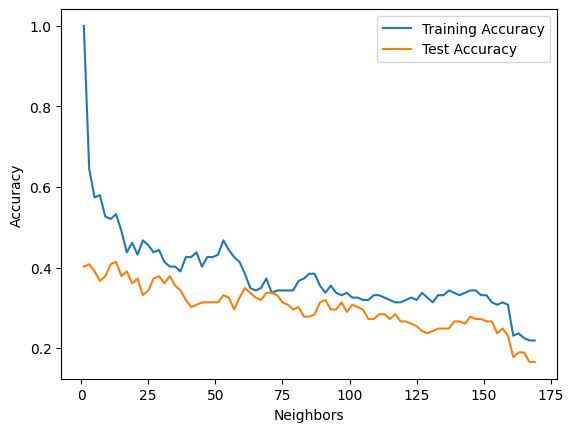

[13]
col_0       1   2   3  4   5
mine_type                   
1          25   0  10  0   3
2           0  22   6  3   4
3           2   3  11  1  16
4          15   0   9  4   7
5           7   2  11  0   8


0.41420118343195267

In [4]:
#Part 1
mines_df = pd.read_csv('data/land_mines.csv')
mines_df.describe()

sns.countplot(x='mine_type', data=mines_df)
plt.title('Mine Type Distribution')
plt.show()

sns.pairplot(mines_df, hue='mine_type', vars=['voltage', 'height', 'soil'])
plt.show()

#Part 2
X = mines_df[["voltage", "height", "soil"]]
y = mines_df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=100)

#Part 3
k_grid = np.array([(2*k+1) for k in range(0, 85)])
test_accuracy = []
train_accuracy = []

for k in k_grid:
    model = Pipeline(steps=[
        ("scaler", MinMaxScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    model = model.fit(X_train, y_train)
    y_hat = model.predict(X_test)
    test_acc = model.score(X_test, y_test)
    train_acc = model.score(X_train, y_train)

    print(f"Test accuracy for {k} neighbors is {test_acc}; train accuracy for {k} neighbors is {train_acc}")
    test_accuracy.append(test_acc)
    train_accuracy.append(train_acc)

sns.lineplot(x=k_grid, y=train_accuracy, label="Training Accuracy").set(xlabel="Neighbors", ylabel="Accuracy")
sns.lineplot(x=k_grid, y=test_accuracy, label="Test Accuracy")
plt.show()

#Part 4
optimal = test_accuracy == np.max(test_accuracy)
optimal_indices = np.where(optimal)
optimal_k = k_grid[optimal_indices]

print(optimal_k)

#Part 5
model_best = Pipeline(steps=[
    ("scaler", MinMaxScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=13))
])

model_best.fit(X_train, y_train)

y_hat = model_best.predict(X_test)
print(pd.crosstab(y_test, y_hat))
model_best.score(X_test, y_test)


**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?

- As you increase K, the predictions are packed tighter together and show less variable. Predictions start to cluster towards the mean price which could mean that the model starts to over-average across too many neighbors and loses sensitivity to individuals (underfitting).

5. Determine the optimal $k$ for these data.

- The optimal k for these data is 77.

6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)
When the k is too low, the model is overfitting and causes it to be too sensitive to individual training points and ignores overall trends. However, when the k is too high, the model is underfitting as it ignores individual training points and empahsizes overall trends as it averages too many neighbors and points towards the mean.


   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654
(2499, 3)


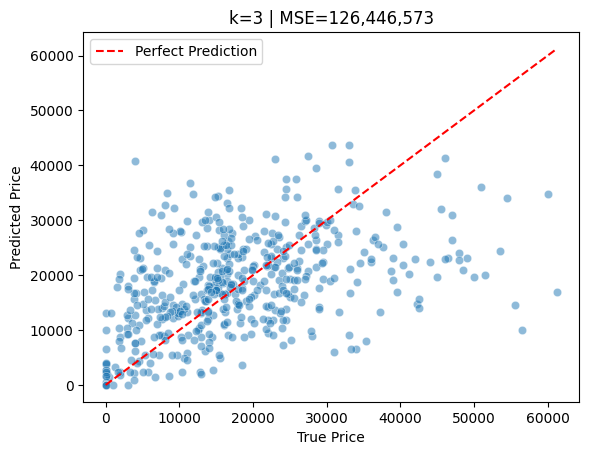

k=3: MSE = 126,446,573.22


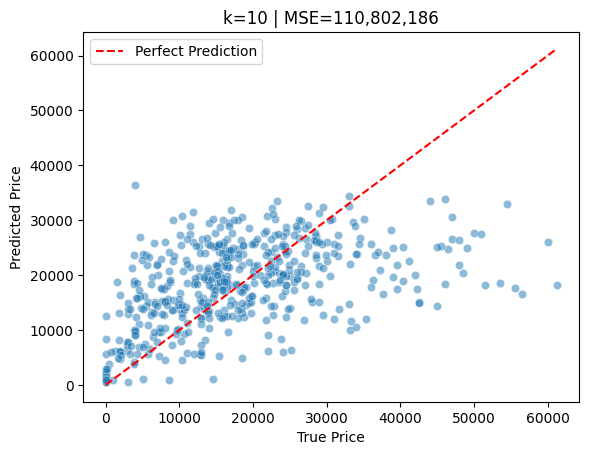

k=10: MSE = 110,802,185.59


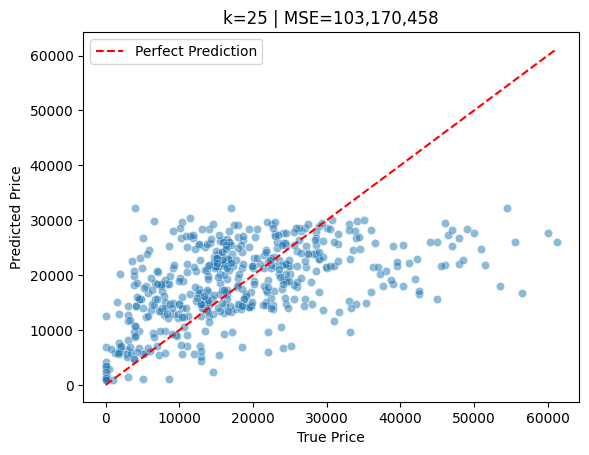

k=25: MSE = 103,170,457.85


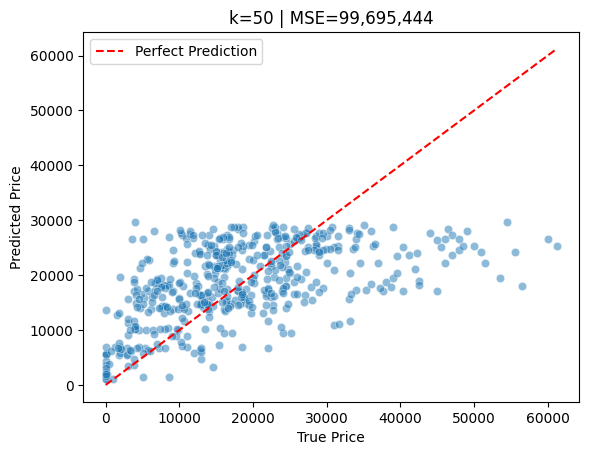

k=50: MSE = 99,695,443.96


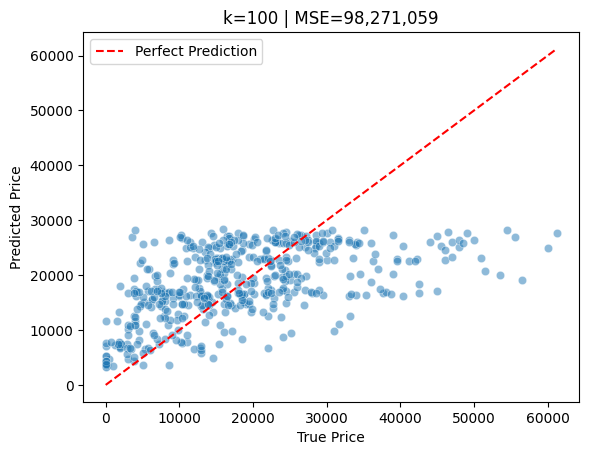

k=100: MSE = 98,271,058.96


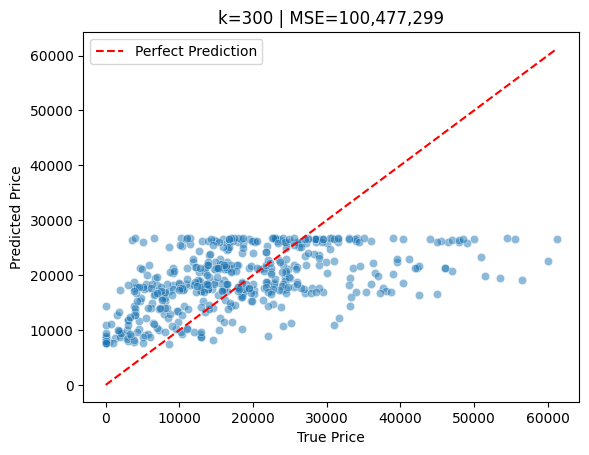

k=300: MSE = 100,477,298.91
Optimal k: 77
Optimal Test MSE: 97988032.50151458


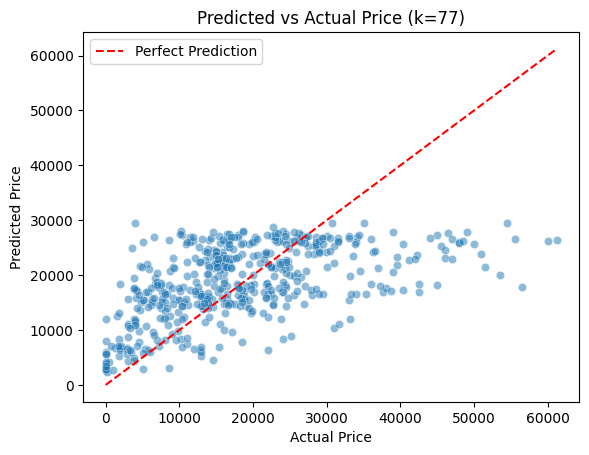

In [14]:
#Part 1
car_df = pd.read_csv('./data/USA_cars_datasets.csv')
car_df = car_df[['price', 'year', 'mileage']]
print(car_df.head())
print(car_df.shape)

#Part 2
def minmax(x):
    u = (x - min(x)) / (max(x) - min(x))
    return u
car_df["year_norm"] = minmax(car_df["year"])
car_df["mileage_norm"] = minmax(car_df["mileage"])

#Part 3
X = car_df[["year_norm", "mileage_norm"]]
y = car_df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

k_values = [3, 10, 25, 50, 100, 300]

#Part 4
for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_hat = model.predict(X_test)

    mse = mean_squared_error(y_test, y_hat)

    plt.figure()
    sns.scatterplot(x=y_test, y=y_hat, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color='red', linestyle='--', label='Perfect Prediction')
    plt.xlabel('True Price')
    plt.ylabel('Predicted Price')
    plt.title(f'k={k} | MSE={mse:,.0f}')
    plt.legend()
    plt.show()

    print(f'k={k}: MSE = {mse:,.2f}')

    k_grid = np.array([k for k in range(1, 150)])
test_mses = []
train_mses = []

for k in k_grid:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)

    train_mse = mean_squared_error(y_train, model.predict(X_train))
    test_mse = mean_squared_error(y_test, model.predict(X_test))

    train_mses.append(train_mse)
    test_mses.append(test_mse)


test_mses = np.array(test_mses)
k_optimal = k_grid[np.argmin(test_mses)]
print(f"Optimal k: {k_optimal}")
print(f"Optimal Test MSE: {test_mses.min()}")

model = KNeighborsRegressor(n_neighbors=k_optimal)
model.fit(X_train, y_train)
y_hat = model.predict(X_test)

plt.figure()
sns.scatterplot(x=y_test, y=y_hat, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Predicted vs Actual Price (k={k_optimal})')
plt.legend()
plt.show()

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

- The 2 KDE plots look quite different from each other. This may be because the training ratings are spread out over a wider range. In contrast, the predicted ratings are more closely packed together, around 80 to around 100. Thus, the model fails to predict for a full range of variability and instead tends to regress towards the mean in terms of predictions.

k=3, MSE=109.46280804883564
k=5, MSE=90.57613384580603
k=10, MSE=79.26373954329641
k=25, MSE=73.89787022382998
k=50, MSE=72.59361944381642
k=100, MSE=71.75795568618584
Best k: 100
Best MSE: 71.75795568618584


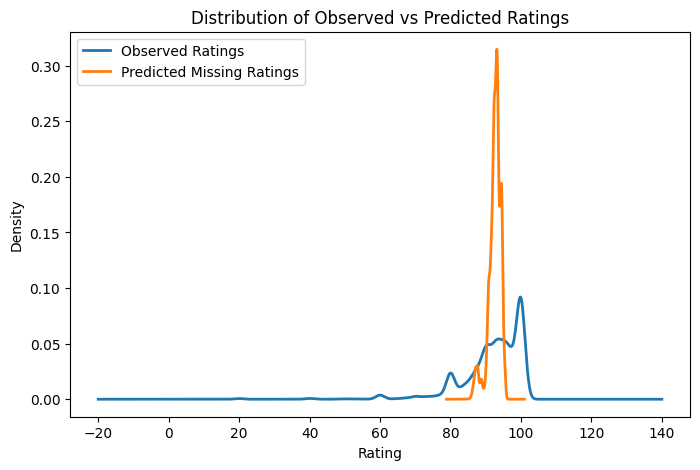

In [21]:
#Part 1
airbnb_df = pd.read_csv("data/airbnb_hw.csv")
airbnb_df = airbnb_df.loc[:, ["Review Scores Rating", "Price", "Beds"]]

airbnb_df["Price"] = airbnb_df["Price"].astype(str).str.replace("$", "").str.replace(",", "")
airbnb_df["Price"] = pd.to_numeric(airbnb_df["Price"], errors="coerce")
airbnb_df["Beds"] = pd.to_numeric(airbnb_df["Beds"], errors="coerce")
airbnb_df["Review Scores Rating"] = pd.to_numeric(airbnb_df["Review Scores Rating"], errors="coerce")

#Part 2
missing_df = airbnb_df.loc[airbnb_df["Review Scores Rating"].isnull()]

#Part 3
airbnb_df = airbnb_df.dropna(axis=0, how="any")

#Part 4
X = airbnb_df[["Price", "Beds"]]
y = airbnb_df["Review Scores Rating"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_k = None
best_mse = None

for k in [3, 5, 10, 25, 50, 100]:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)

    if best_mse is None or mse < best_mse:
        best_mse = mse
        best_k = k

    print(f"k={k}, MSE={mse}")

print("Best k:", best_k)
print("Best MSE:", best_mse)

final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(X, y)

#Part 5
X_missing = missing_df[["Price", "Beds"]].dropna()
predicted_missing = final_model.predict(X_missing)

missing_df = missing_df.copy()
missing_df["Predicted Rating"] = None
missing_df.loc[X_missing.index, "Predicted Rating"] = predicted_missing

#Part 6
plt.figure(figsize=(8, 5))
y.plot(kind="kde", label="Observed Ratings", linewidth=2)
pd.Series(pred_missing).plot(kind="kde", label="Predicted Missing Ratings", linewidth=2)

plt.xlabel("Rating")
plt.title("Distribution of Observed vs Predicted Ratings")
plt.legend()
plt.show()

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)